<a href="https://colab.research.google.com/github/gburv25-collab/L4-Data-Analysis/blob/main/Week2_Part2_Two_Group_Differences_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Advanced Statistics  
## Part 2: Two-Group Differences

**Dataset:** `IBM_HR_Analytics.csv`  
**Tools:** Python / Google Colab  

This notebook covers:

1. Group summaries  
2. Distribution and boxplot checks  
3. Shapiro-Wilk normality checks  
4. Levene's test for equal variance  
5. Welch's independent samples t-test  
6. Mann–Whitney U test  
7. Cautious business interpretation  

The main question is:

**Does MonthlyIncome differ between employees who left and employees who stayed?**

## Before You Start

Upload `IBM_HR_Analytics.csv` into the same Colab session before running the code.

Mann–Whitney U is included as a **common non-parametric alternative** for comparing two independent groups, especially when the outcome is ordinal, skewed, or affected by outliers. It should not be described as an identical substitute for a t-test.

In [ ]:
# ============================================================
# Week 2: Advanced Statistics
# Part 2: Two-Group Differences
# Dataset: IBM_HR_Analytics.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import (
    ttest_ind,
    mannwhitneyu,
    levene,
    shapiro
)

## 1. Load the Dataset

In [ ]:
# Load the dataset

df = pd.read_csv("IBM_HR_Analytics.csv")

# Show the first few rows
display(df.head())

# Show dataset information
df.info()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

## 2. Check the Variables Used in This Notebook

In [ ]:
# Key variables for Part 2

key_variables = [
    "Attrition",
    "MonthlyIncome"
]

# Check the columns exist
missing_columns = [col for col in key_variables if col not in df.columns]

if missing_columns:
    raise ValueError(f"The following expected columns are missing: {missing_columns}")

display(df[key_variables].head())

,Attrition,MonthlyIncome
0,Yes,5993
1,No,5130
2,Yes,2090
3,No,2909
4,No,3468


In [ ]:
# Check data types and missing values

print("Data types:")
display(df[key_variables].dtypes)

print("\nMissing values:")
display(df[key_variables].isna().sum())

Data types:


,0
Attrition,object
MonthlyIncome,int64



Missing values:


,0
Attrition,0
MonthlyIncome,0


# Practical 3: Two-Group Difference  
## Does MonthlyIncome differ between employees who left and employees who stayed?

| Role | Variable | Type |
|---|---|---|
| Grouping variable | Attrition | Nominal: Yes / No |
| Outcome variable | MonthlyIncome | Numerical |

Possible methods:

- **Welch's independent samples t-test** if a parametric approach is reasonable
- **Mann–Whitney U** if a non-parametric approach is safer

## 3. Select the Variables

In [ ]:
# Select relevant variables and remove missing values for this analysis

group_data = df[["Attrition", "MonthlyIncome"]].dropna()

display(group_data.head())
print("Number of rows used:", len(group_data))

,Attrition,MonthlyIncome
0,Yes,5993
1,No,5130
2,Yes,2090
3,No,2909
4,No,3468


Number of rows used: 1470


## 4. Group Summary

In [ ]:
# Summary by Attrition group

group_summary = group_data.groupby("Attrition")["MonthlyIncome"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

display(group_summary)

,count,mean,median,std,min,max
Attrition,,,,,,
No,1233,6832.739659,5204.0,4818.208001,1051,19999
Yes,237,4787.092827,3202.0,3640.210367,1009,19859


## 5. Visualise the Groups

/tmp/ipykernel_927/2246643836.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(groups, labels=group_labels)


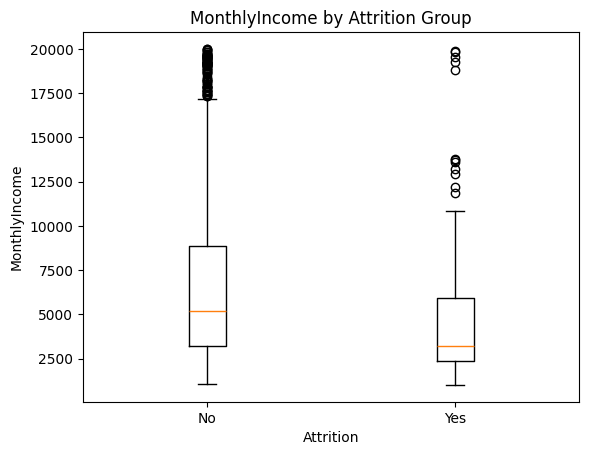

In [ ]:
# Boxplot by Attrition group

group_labels = sorted(group_data["Attrition"].unique())

groups = [
    group_data[group_data["Attrition"] == group]["MonthlyIncome"]
    for group in group_labels
]

plt.boxplot(groups, labels=group_labels)
plt.xlabel("Attrition")
plt.ylabel("MonthlyIncome")
plt.title("MonthlyIncome by Attrition Group")
plt.show()

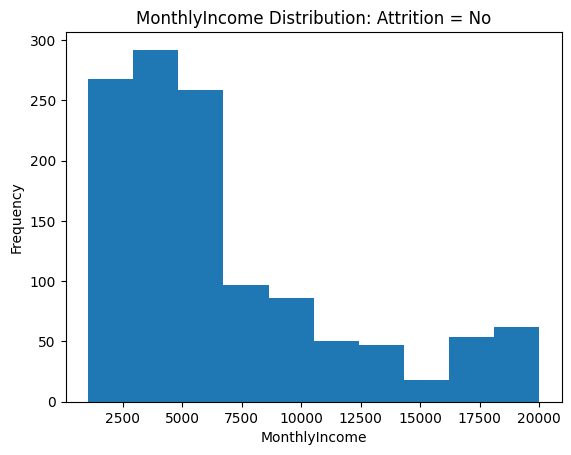

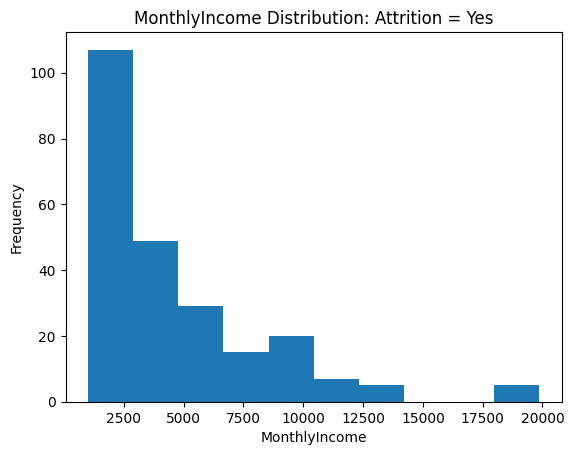

In [ ]:
# Histograms by group

for group in group_labels:
    subset = group_data[group_data["Attrition"] == group]["MonthlyIncome"]

    plt.hist(subset)
    plt.title(f"MonthlyIncome Distribution: Attrition = {group}")
    plt.xlabel("MonthlyIncome")
    plt.ylabel("Frequency")
    plt.show()

## 6. Assumption Checks

Before choosing between t-test and Mann–Whitney U, consider:

- Are there two independent groups?
- Is the outcome numerical or ordinal?
- Are there major outliers?
- Is the outcome approximately normal within each group?
- Are variances reasonably similar?
- Would a non-parametric method be safer?

## 7. Prepare Groups for Testing

In [ ]:
# Split MonthlyIncome into two groups

income_no = group_data[group_data["Attrition"] == "No"]["MonthlyIncome"]
income_yes = group_data[group_data["Attrition"] == "Yes"]["MonthlyIncome"]

print("Attrition = No:", len(income_no))
print("Attrition = Yes:", len(income_yes))

Attrition = No: 1233
Attrition = Yes: 237


## 8. Check Normality

The Shapiro-Wilk test can be useful, but it can be sensitive with larger samples. Use it alongside histograms, boxplots and descriptive summaries.

In [ ]:
# Shapiro-Wilk normality test

shapiro_no = shapiro(income_no)
shapiro_yes = shapiro(income_yes)

print("Shapiro test for Attrition = No")
print("Statistic:", shapiro_no.statistic)
print("p-value:", shapiro_no.pvalue)

print("\nShapiro test for Attrition = Yes")
print("Statistic:", shapiro_yes.statistic)
print("p-value:", shapiro_yes.pvalue)

Shapiro test for Attrition = No
Statistic: 0.8341343315055664
p-value: 5.9703792392981e-34

Shapiro test for Attrition = Yes
Statistic: 0.7798968527150191
p-value: 1.5025414983521328e-17


## 9. Check Equal Variance

In [ ]:
# Levene's test for equal variance

levene_stat, levene_p = levene(income_no, income_yes)

print("Levene statistic:", levene_stat)
print("Levene p-value:", levene_p)

if levene_p < 0.05:
    print("There is evidence that variances differ. Welch's t-test may be safer than the standard t-test.")
else:
    print("There is insufficient evidence that variances differ.")

Levene statistic: 14.899586974568717
Levene p-value: 0.00011830973427184532
There is evidence that variances differ. Welch's t-test may be safer than the standard t-test.


## 10. Run Welch's Independent Samples t-test

Using `equal_var=False` runs Welch's t-test, which is usually safer when variances may not be equal.

In [ ]:
# Welch's independent samples t-test

t_stat, t_p = ttest_ind(
    income_no,
    income_yes,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", t_p)

t-statistic: 7.482621586644742
p-value: 4.433588628286071e-13


## 11. Run Mann–Whitney U Test

Mann–Whitney U is a common non-parametric alternative when comparing two independent groups, especially where the outcome is ordinal, skewed or affected by outliers.

It is not interpreted in exactly the same way as a t-test.

In [ ]:
# Mann–Whitney U test

u_stat, u_p = mannwhitneyu(
    income_no,
    income_yes,
    alternative="two-sided"
)

print("Mann–Whitney U statistic:", u_stat)
print("p-value:", u_p)

Mann–Whitney U statistic: 191600.5
p-value: 2.950830917288873e-14


## 12. Present Results Together

In [ ]:
difference_results = pd.DataFrame({
    "Test": ["Welch's t-test", "Mann–Whitney U"],
    "Test statistic": [t_stat, u_stat],
    "p-value": [t_p, u_p]
})

display(difference_results)

,Test,Test statistic,p-value
0,Welch's t-test,7.482622,4.433589e-13
1,Mann–Whitney U,191600.500000,2.950831e-14


## 13. Interpret Group Difference Results

In [ ]:
def interpret_difference_p_value(p):
    if p < 0.05:
        return "evidence of a difference between the groups in the sample"
    else:
        return "insufficient evidence of a difference between the groups in the sample"


print("t-test interpretation:")
print(interpret_difference_p_value(t_p))

print("\nMann–Whitney U interpretation:")
print(interpret_difference_p_value(u_p))

t-test interpretation:
evidence of a difference between the groups in the sample

Mann–Whitney U interpretation:
evidence of a difference between the groups in the sample


In [ ]:
# Example cautious reporting sentence
# Change chosen_test and chosen_p depending on which result you decide is most appropriate to report.

chosen_test = "Mann–Whitney U test"
chosen_p = u_p

print(
    f"A {chosen_test} was used to compare MonthlyIncome between employees "
    f"who left and employees who stayed. The p-value was {chosen_p:.5f}, "
    f"suggesting {interpret_difference_p_value(chosen_p)}. This should be "
    f"interpreted cautiously because the result does not prove that income "
    f"caused attrition."
)

A Mann–Whitney U test was used to compare MonthlyIncome between employees who left and employees who stayed. The p-value was 0.00000, suggesting evidence of a difference between the groups in the sample. This should be interpreted cautiously because the result does not prove that income caused attrition.


## 14. Statistical Significance vs Practical Importance

In [ ]:
print("""
Business interpretation prompts:

1. What statistical test did you use?
2. Which variables were analysed?
3. Was there evidence of a difference in the sample?
4. Is the result statistically significant?
5. Is the result practically important?
6. What other explanations could there be?
7. What caution or limitation should be included?
""")


Business interpretation prompts:

1. What statistical test did you use?
2. Which variables were analysed?
3. Was there evidence of a difference in the sample?
4. Is the result statistically significant?
5. Is the result practically important?
6. What other explanations could there be?
7. What caution or limitation should be included?



## 15. Reflection Questions

Answer these in your worksheet:

1. What did the group summaries show?
2. Did the boxplot or histograms suggest outliers or skewness?
3. What did Levene's test suggest about variance?
4. Which result would you report: t-test or Mann–Whitney U?
5. Why is Mann–Whitney U not identical to a t-test?
6. What cautious business conclusion could you write?
7. Is the result practically important, or only statistically significant?